### Plot costs for training

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_training_cost(csv_path, show=True, save_path=None):
    """
    Load training cost CSV and plot it.
    
    Args:
        csv_path (str): Path to the CSV file.
        show (bool): Whether to show the plot immediately.
        save_path (str or None): If given, save the plot to this path.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    # Load CSV
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)  # skip header if present

    # Handle two cases: CSV with steps or just values
    if data.ndim == 1 or data.shape[1] == 1:
        steps = np.arange(1, len(data) + 1)
        costs = data.flatten()
    else:
        steps = data[:, 0]
        costs = data[:, 1]

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(steps, costs, label="Training Cost")
    plt.xlabel("Step")
    plt.ylabel("Cost")
    plt.title("Training Cost over Steps")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    if show:
        plt.show()


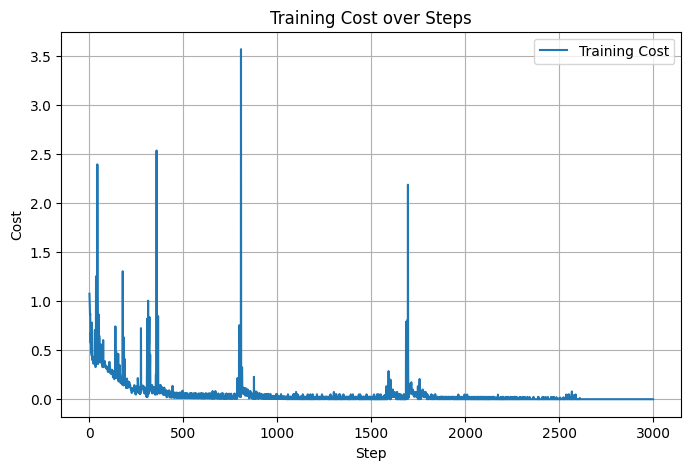

In [2]:
csv_path = "outputs/train_costs.csv"
plot_training_cost(csv_path)

Plot saved as metrics_plot.png


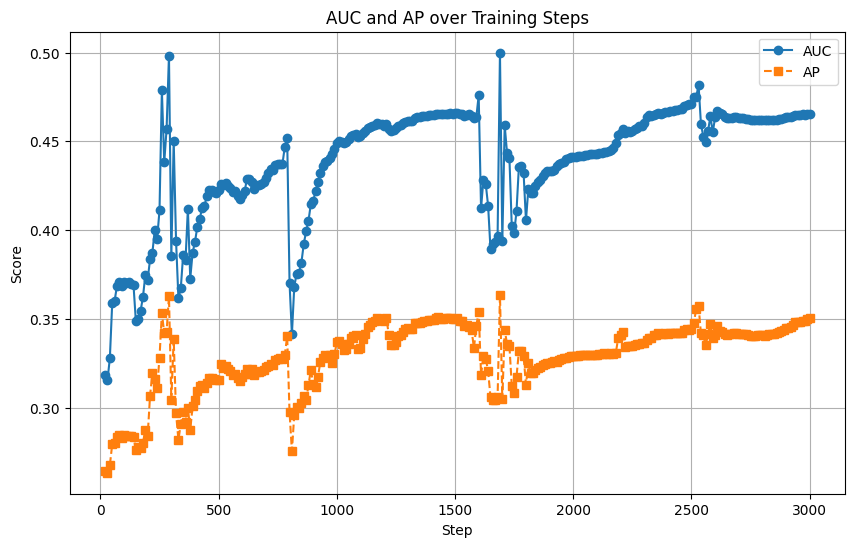

In [ ]:
### Plot AUC over time 
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
# Assuming your CSV file is named 'metrics.csv'
df = pd.read_csv('./outputs/test_metrics.csv')

# 2. Set up the plot
plt.figure(figsize=(10, 6))

# Plotting AUC
plt.plot(df['step'], df['auc'], label='AUC', marker='o', linestyle='-')

# Plotting AP
plt.plot(df['step'], df['ap'], label='AP', marker='s', linestyle='--')

# 3. Add labels and title
plt.xlabel('Step')
plt.ylabel('Score')
plt.title('AUC and AP over Training Steps')
plt.legend()
plt.grid(True)

### Visualize anomalies in video

In [ ]:
import os
import random
import re
import cv2
import torch
import numpy as np
from torch.utils.data import DataLoader
from components.model import WSAD
from components.dataset_loader import FeatureDataset

# ============================================================
# Inference
# ============================================================
def run_inference(model, test_loader, snippet_frame_count=16):
    model.eval()
    model.flag = "Test"

    snippet_scores_dict = {}

    with torch.no_grad():
        for data, label, name in test_loader:
            name = name[0] if isinstance(name, (list, tuple)) else str(name)
            data = data.cuda()

            out = model(data)
            snippet_scores = out["frame"].squeeze().cpu().numpy()
            snippet_scores_dict[name] = snippet_scores

    return snippet_scores_dict

# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":

    # VIDEO_ROOT = "data/test"  # folder with your video files

    # ---- load model ----
    model = WSAD(input_size=1024, flag="Test", a_nums=60, n_nums=60).cuda()
    model_path = "models/trained/v4_4_crop_finetuned_model/ur_dmu_best2022.pkl"
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # ---- load test dataset ----
    test_loader = DataLoader(
        FeatureDataset(
            root_dir="./feature_embeddings/v4_4_crop_finetuned_model",
            modal="RGB",
            mode="Test",
            num_segments=200,
            len_feature=1024
        ),
        batch_size=1,
        shuffle=False,
        num_workers=2
    )

    # ---- inference ----
    snippet_scores_dict = run_inference(model, test_loader)

  
    

/tmp/ipykernel_2965673/2110697824.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


TypeError: FeatureDataset.__init__() got an unexpected keyword argument 'root_dir'

In [8]:
snippet_scores_dict.keys()

dict_keys(['video_eo_96_500_ab_i3d.npy', 'video_eo_96_2485_ab_i3d.npy', 'video_eo_96_4100_ab_i3d.npy', 'video_eo_96_5620_ab_i3d.npy', 'video_eo_96_11025_ab_i3d.npy', 'video_eo_96_15365_ab_i3d.npy', 'video_eo_96_20945_ab_i3d.npy', 'video_eo_96_21913_ab_i3d.npy', 'video_eo_96_0_norm_i3d.npy', 'video_eo_96_1816_norm_i3d.npy', 'video_eo_96_2263_norm_i3d.npy', 'video_eo_96_3021_norm_i3d.npy', 'video_eo_96_3468_norm_i3d.npy', 'video_eo_96_3915_norm_i3d.npy', 'video_eo_96_4711_norm_i3d.npy', 'video_eo_96_5158_norm_i3d.npy', 'video_eo_96_6821_norm_i3d.npy', 'video_eo_96_7268_norm_i3d.npy', 'video_eo_96_7715_norm_i3d.npy', 'video_eo_96_8162_norm_i3d.npy', 'video_eo_96_8609_norm_i3d.npy', 'video_eo_96_9056_norm_i3d.npy', 'video_eo_96_9503_norm_i3d.npy', 'video_eo_96_9950_norm_i3d.npy', 'video_eo_96_10397_norm_i3d.npy', 'video_eo_96_10844_norm_i3d.npy', 'video_eo_96_11426_norm_i3d.npy', 'video_eo_96_11873_norm_i3d.npy', 'video_eo_96_12320_norm_i3d.npy', 'video_eo_96_12767_norm_i3d.npy', 'video_eo

In [2]:
import numpy as np

# Filter snippets with at least one score in the desired range
target_snippets = snippet_scores_dict

print(f"Found {len(target_snippets)} snippets containing scores in range [0.05, 1]:\n")

# Separate lists for 'ab' and 'norm'
ab_scores = []
norm_scores = []

for filename, scores in target_snippets.items():
    max_score = np.max(scores)
    # print(f"{filename}: Max Score = {max_score:.4f}")
    
    if 'ab' in filename.lower():
        ab_scores.append(np.mean(scores))  # Average score per video
        # print(filename.lower())
    elif 'norm' in filename.lower():
        norm_scores.append(np.mean(scores))

# Compute averages per group
avg_ab = np.mean(ab_scores) if ab_scores else float('nan')
avg_norm = np.mean(norm_scores) if norm_scores else float('nan')

print(f"\nAverage score for videos with 'ab' in the name: {avg_ab:.4f}")
print(f"Average score for videos with 'norm' in the name: {avg_norm:.4f}")


Found 59 snippets containing scores in range [0.05, 1]:


Average score for videos with 'ab' in the name: 0.0336
Average score for videos with 'norm' in the name: 0.0001


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare lists for all scores
ab_scores_all = []
norm_scores_all = []

for filename, scores in snippet_scores_dict.items():
    if 'ab' in filename.lower():
        ab_scores_all.extend(scores)
    elif 'norm' in filename.lower():
        norm_scores_all.extend(scores)

# Combine all scores for single-column plot
all_scores = ab_scores_all + norm_scores_all

# Boxplot (single column)
plt.figure(figsize=(8,6))
sns.boxplot(y=all_scores, color='lightgray', showfliers=False)

# Scatter points with jitter
y_jitter_ab = np.array(ab_scores_all)
y_jitter_norm = np.array(norm_scores_all)

x_jitter_ab = np.random.normal(loc=0, scale=0.05, size=len(ab_scores_all))
x_jitter_norm = np.random.normal(loc=0, scale=0.05, size=len(norm_scores_all))

plt.scatter(x_jitter_ab, y_jitter_ab, color='red', alpha=0.4, s=10, label='AB (Anomalous)')
plt.scatter(x_jitter_norm, y_jitter_norm, color='green', alpha=0.4, s=10, label='NORM (Normal)')

plt.xticks([])  # remove x-tick labels
plt.ylabel('Snippet Scores')
plt.title('Distribution of All Snippet Scores (Normal vs Anomalous)')
plt.legend()
plt.show()


NameError: name 'snippet_scores_dict' is not defined

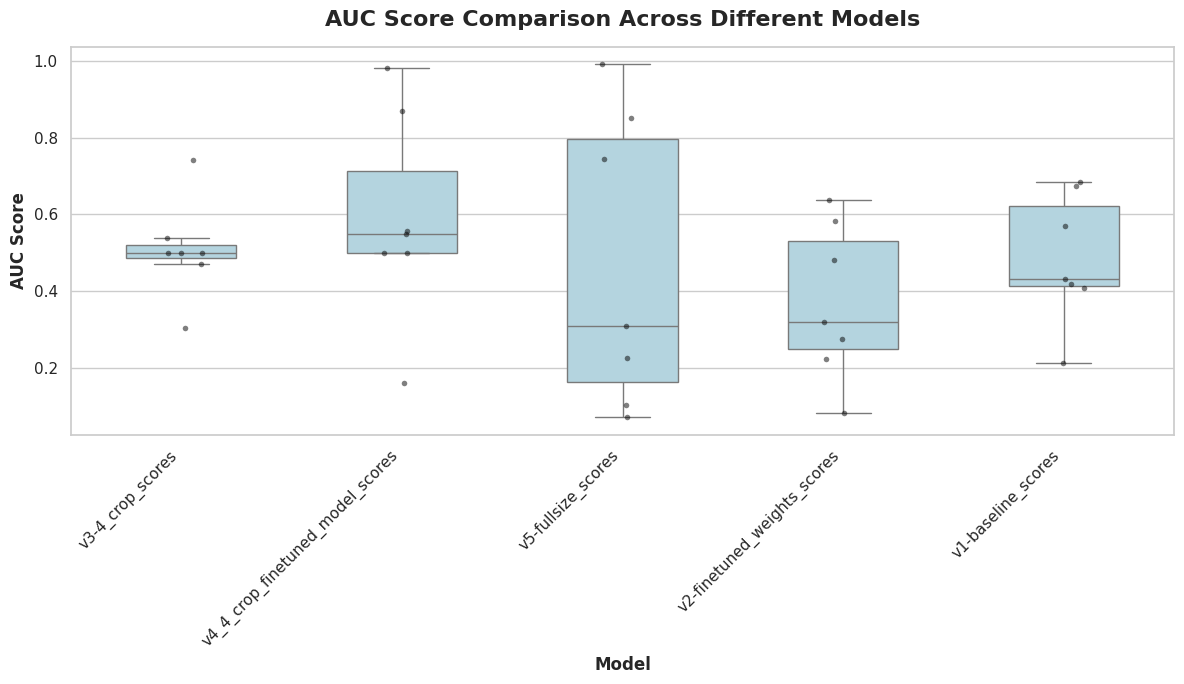

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# ==========================================
# 1. SET YOUR FOLDER PATH HERE
# ==========================================
# Replace with the path to your folder containing the 7 CSVs
folder_path = r"debug_plots/auc_per_video" 

# ==========================================
# 2. LOAD AND COMBINE THE CSVS
# ==========================================
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

if not csv_files:
    print(f"No CSV files found in {folder_path}. Please check the path.")
else:
    all_data = []
    
    for file in csv_files:
        df = pd.read_csv(file)
        # Use filename as Model Name
        model_name = os.path.basename(file).replace('.csv', '')
        df['Model'] = model_name
        all_data.append(df)
    
    # Combine into one dataframe
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Sort by video name so the X-axis is organized alphabetically
    combined_df = combined_df.sort_values(by='name')

# ==========================================
# 3. PLOT THE SCATTER GRAPH
# ==========================================
    # Set a large figure size so the video names on the X-axis fit properly
    plt.figure(figsize=(16, 8))
    sns.set_theme(style="whitegrid")
    
    # Create the scatter plot
    # x='name' puts videos on the bottom, hue='Model' gives each CSV a different color
    sns.scatterplot(
        data=combined_df, 
        x='name', 
        y='auc', 
        hue='Model', 
        palette='tab10', # A color palette that makes distinct colors
        s=100,           # Size of the dots
        alpha=0.8        # Slight transparency in case dots overlap
    )
    
    # Formatting
    plt.title('Individual Video AUC Comparison Across Models', fontsize=18, fontweight='bold', pad=15)
    plt.ylabel('AUC Score', fontsize=14, fontweight='bold')
    plt.xlabel('Video Name', fontsize=14, fontweight='bold')
    
    # Rotate the video names 90 degrees so they don't overlap
    plt.xticks(rotation=90, fontsize=10)
    
    # Move the legend outside the plot so it doesn't cover your data dots
    plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    # Adjust layout to fit the rotated x-labels and the legend
    plt.tight_layout()
    
    # Show the plot
    plt.show()